![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World!

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [10]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("/crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [ ]:
# Start coding here
# Use as many cells as you need

In [12]:
crimes.info()
crimes.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  object
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(2), object(10)
memory usage: 17.0+ MB


,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,11
Vict Descent,10
Weapon Desc,112213


In [13]:
crimes.columns = crimes.columns.str.lower().str.replace(" ", "_")
crimes.columns

Index(['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area_name',
       'crm_cd_desc', 'vict_age', 'vict_sex', 'vict_descent', 'weapon_desc',
       'status_desc', 'location'],
      dtype='object')

In [14]:
crimes.drop_duplicates(inplace=True)

In [15]:
crimes['date_rptd'] = pd.to_datetime(crimes['date_rptd'], errors='coerce')
crimes['date_occ'] = pd.to_datetime(crimes['date_occ'], errors='coerce')

In [16]:
crimes['time_occ'] = crimes['time_occ'].str.zfill(4)
crimes['time_occ'] = pd.to_datetime(crimes['time_occ'], format='%H%M', errors='coerce')

In [17]:
crimes.isnull().sum()

,0
dr_no,0
date_rptd,0
date_occ,0
time_occ,0
area_name,0
crm_cd_desc,0
vict_age,0
vict_sex,11
vict_descent,10
weapon_desc,112213


In [18]:
crimes.dropna(subset=['date_occ', 'crm_cd_desc', 'area_name'], inplace=True)

crimes['vict_age'].fillna(crimes['vict_age'].median(), inplace=True)

crimes['vict_sex'].fillna('X', inplace=True)

crimes['weapon_desc'].fillna('No Weapon', inplace=True)

/tmp/ipykernel_6360/1135240253.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  crimes['vict_age'].fillna(crimes['vict_age'].median(), inplace=True)
/tmp/ipykernel_6360/1135240253.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [19]:
crimes = crimes[(crimes['vict_age'] > 0) & (crimes['vict_age'] < 100)]

In [20]:
crimes['crm_cd_desc'] = crimes['crm_cd_desc'].str.lower().str.strip()
crimes['area_name'] = crimes['area_name'].str.title().str.strip()

In [21]:
crimes['vict_sex'] = crimes['vict_sex'].apply(
    lambda x: 'Male' if x == 'M' else ('Female' if x == 'F' else 'Unspecified')
)

In [22]:
crimes.drop(['dr_no', 'location'], axis=1, inplace=True)

In [23]:
crimes['year'] = crimes['date_occ'].dt.year
crimes['month'] = crimes['date_occ'].dt.month
crimes['hour'] = crimes['time_occ'].dt.hour

In [34]:
crimes.info()
crimes.head()

<class 'pandas.core.frame.DataFrame'>
Index: 185319 entries, 0 to 185714
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date_rptd     185319 non-null  datetime64[ns]
 1   date_occ      185319 non-null  datetime64[ns]
 2   time_occ      185319 non-null  datetime64[ns]
 3   area_name     185319 non-null  object        
 4   crm_cd_desc   185319 non-null  object        
 5   vict_age      185319 non-null  int64         
 6   vict_sex      185319 non-null  object        
 7   vict_descent  185319 non-null  object        
 8   weapon_desc   185319 non-null  object        
 9   status_desc   185319 non-null  object        
 10  year          185319 non-null  int32         
 11  month         185319 non-null  int32         
 12  hour          185319 non-null  int32         
dtypes: datetime64[ns](3), int32(3), int64(1), object(6)
memory usage: 17.7+ MB


,date_rptd,date_occ,time_occ,area_name,crm_cd_desc,vict_age,vict_sex,vict_descent,weapon_desc,status_desc,year,month,hour
0,2022-07-22,2020-05-12,1900-01-01 11:10:00,Southwest,theft of identity,27,Female,B,No Weapon,Invest Cont,2020,5,11
1,2022-08-06,2020-06-04,1900-01-01 16:20:00,Olympic,theft of identity,60,Male,H,No Weapon,Invest Cont,2020,6,16
2,2022-08-18,2020-08-17,1900-01-01 12:00:00,Hollywood,theft of identity,28,Male,H,No Weapon,Invest Cont,2020,8,12
3,2023-02-27,2020-01-27,1900-01-01 06:35:00,77Th Street,theft of identity,37,Male,H,No Weapon,Invest Cont,2020,1,6
4,2022-07-14,2020-07-14,1900-01-01 09:00:00,Rampart,theft of identity,79,Male,B,No Weapon,Invest Cont,2020,7,9


In [39]:
crimes.to_csv("cleaned_crimes.csv", index=False)

In [27]:
crimes.isnull().sum()

,0
date_rptd,0
date_occ,0
time_occ,0
area_name,0
crm_cd_desc,0
vict_age,0
vict_sex,0
vict_descent,10
weapon_desc,0
status_desc,0


In [28]:
crimes['vict_descent'].fillna('Unknown', inplace=True)

/tmp/ipykernel_6360/3516168679.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  crimes['vict_descent'].fillna('Unknown', inplace=True)


In [29]:
crimes['vict_descent'].isnull().sum()

np.int64(0)

In [30]:
crimes.isnull().sum()

,0
date_rptd,0
date_occ,0
time_occ,0
area_name,0
crm_cd_desc,0
vict_age,0
vict_sex,0
vict_descent,0
weapon_desc,0
status_desc,0


In [33]:
crimes.duplicated().sum()

np.int64(0)

In [32]:
crimes.drop_duplicates(inplace=True)

In [35]:
crimes['vict_age'].describe()

,vict_age
count,185319.000000
mean,40.018509
std,15.445300
min,2.000000
25%,28.000000
50%,37.000000
75%,50.000000
max,99.000000


In [36]:
crimes['vict_sex'].value_counts()

,count
vict_sex,
Male,92801
Female,89714
Unspecified,2804


In [37]:
crimes.groupby('area_name').size().head()

,0
area_name,
77Th Street,11711
Central,14903
Devonshire,7390
Foothill,5969
Harbor,6603


In [38]:
crimes.info()
crimes.describe()
crimes.head()

<class 'pandas.core.frame.DataFrame'>
Index: 185319 entries, 0 to 185714
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date_rptd     185319 non-null  datetime64[ns]
 1   date_occ      185319 non-null  datetime64[ns]
 2   time_occ      185319 non-null  datetime64[ns]
 3   area_name     185319 non-null  object        
 4   crm_cd_desc   185319 non-null  object        
 5   vict_age      185319 non-null  int64         
 6   vict_sex      185319 non-null  object        
 7   vict_descent  185319 non-null  object        
 8   weapon_desc   185319 non-null  object        
 9   status_desc   185319 non-null  object        
 10  year          185319 non-null  int32         
 11  month         185319 non-null  int32         
 12  hour          185319 non-null  int32         
dtypes: datetime64[ns](3), int32(3), int64(1), object(6)
memory usage: 17.7+ MB


,date_rptd,date_occ,time_occ,area_name,crm_cd_desc,vict_age,vict_sex,vict_descent,weapon_desc,status_desc,year,month,hour
0,2022-07-22,2020-05-12,1900-01-01 11:10:00,Southwest,theft of identity,27,Female,B,No Weapon,Invest Cont,2020,5,11
1,2022-08-06,2020-06-04,1900-01-01 16:20:00,Olympic,theft of identity,60,Male,H,No Weapon,Invest Cont,2020,6,16
2,2022-08-18,2020-08-17,1900-01-01 12:00:00,Hollywood,theft of identity,28,Male,H,No Weapon,Invest Cont,2020,8,12
3,2023-02-27,2020-01-27,1900-01-01 06:35:00,77Th Street,theft of identity,37,Male,H,No Weapon,Invest Cont,2020,1,6
4,2022-07-14,2020-07-14,1900-01-01 09:00:00,Rampart,theft of identity,79,Male,B,No Weapon,Invest Cont,2020,7,9


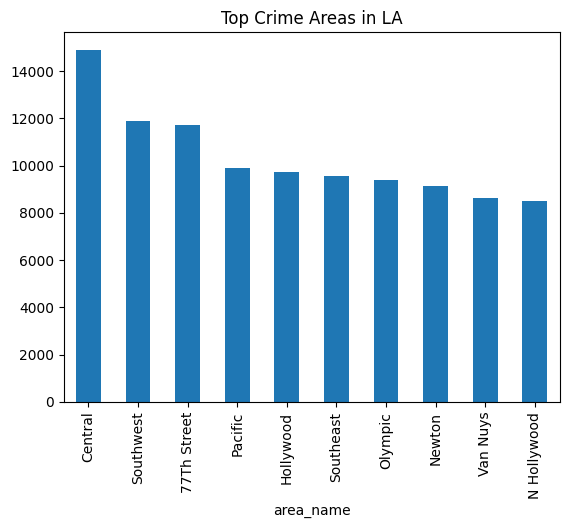

In [40]:
import matplotlib.pyplot as plt

crimes['area_name'].value_counts().head(10).plot(kind='bar')
plt.title("Top Crime Areas in LA")
plt.show()

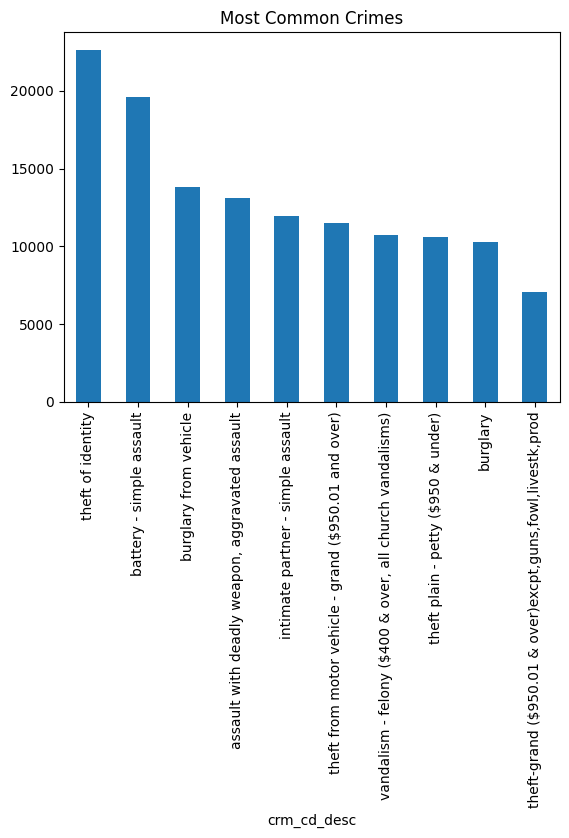

In [41]:
crimes['crm_cd_desc'].value_counts().head(10).plot(kind='bar')
plt.title("Most Common Crimes")
plt.show()

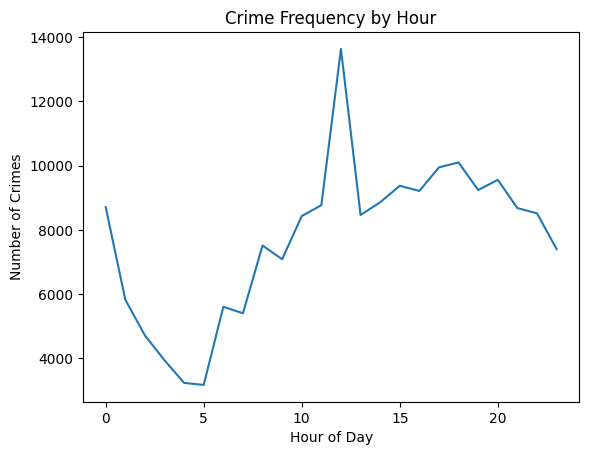

In [42]:
crimes['hour'].value_counts().sort_index().plot(kind='line')
plt.title("Crime Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.show()

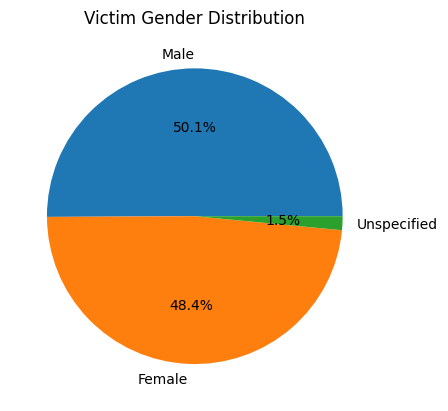

In [43]:
crimes['vict_sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Victim Gender Distribution")
plt.ylabel("")
plt.show()

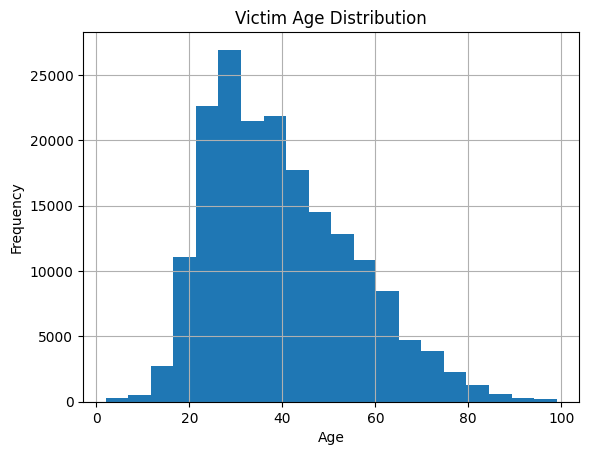

In [44]:
crimes['vict_age'].hist(bins=20)
plt.title("Victim Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

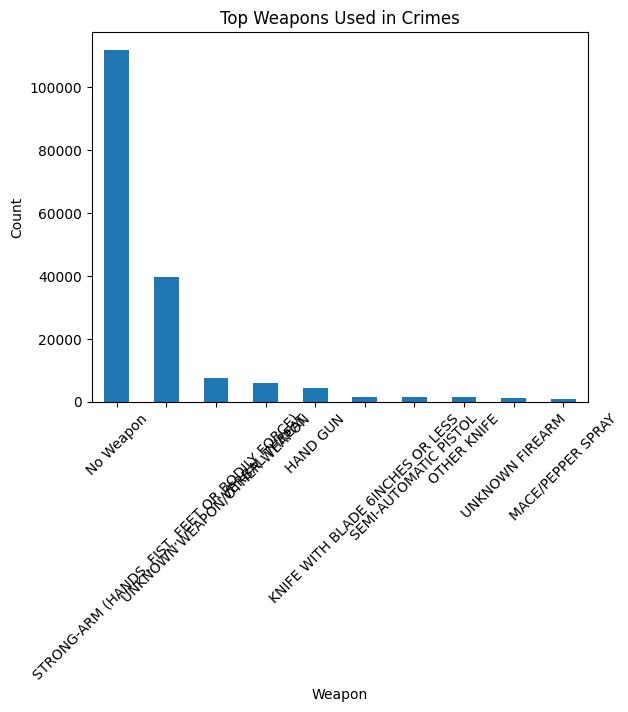

In [45]:
crimes['weapon_desc'].value_counts().head(10).plot(kind='bar')
plt.title("Top Weapons Used in Crimes")
plt.xlabel("Weapon")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()